In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import os

In [3]:
file_path = "/content/drive/MyDrive/Data/ICESAT/is24.parquet"
input_file = pd.read_parquet(file_path)

In [4]:
# display(df.head().T)
display(input_file.columns.tolist())

['delta_time',
 'filename',
 'sc_orient',
 'beam',
 'segment_landcover',
 'rgt',
 'start_cycle',
 'end_cycle',
 'segment_id_beg',
 'segment_id_end',
 'lat',
 'lon',
 'h_canopy',
 'canopy_openness',
 'h_mean_canopy',
 'h_median_canopy',
 'h_dif_canopy',
 'h_min_canopy',
 'h_max_canopy',
 'toc_roughness',
 'h_canopy_quad',
 'n_ca_photons',
 'n_toc_photons',
 'centroid_height',
 'h_canopy_uncertainty',
 'can_noise',
 'dem_h',
 'h_te_best_fit',
 'h_te_interp',
 'h_te_mean',
 'h_te_median',
 'h_te_max',
 'h_te_min',
 'n_te_photons',
 'terrain_slope',
 'brightness_flag',
 'cloud_flag',
 'cloud_fold_flag',
 'dem_flag',
 'dem_removal_flag',
 'layer_flag',
 'msw_flag',
 'night_flag',
 'ph_removal_flag',
 'psf_flag',
 'sat_flag',
 'segment_watermask',
 'snr',
 'terrain_flag',
 'urban_flag',
 'lat_0_20',
 'lat_20_40',
 'lat_40_60',
 'lat_60_80',
 'lat_80_100',
 'long_0_20',
 'long_20_40',
 'long_40_60',
 'long_60_80',
 'long_80_100',
 'h_canopy_0_20',
 'h_canopy_20_40',
 'h_canopy_40_60',
 'h_can

In [5]:
columns_to_select = [
 'lat',
 'lon',
 'h_canopy',
 'canopy_openness',
 'h_mean_canopy',
 'h_median_canopy',
 'h_dif_canopy',
 'h_min_canopy',
 'h_max_canopy',
 'toc_roughness',
 'dem_h',
 'lat_0_20',
 'lat_20_40',
 'lat_40_60',
 'lat_60_80',
 'lat_80_100',
 'long_0_20',
 'long_20_40',
 'long_40_60',
 'long_60_80',
 'long_80_100',
 'h_canopy_0_20',
 'h_canopy_20_40',
 'h_canopy_40_60',
 'h_canopy_60_80',
 'h_canopy_80_100',
 'segmentUID',
 'geoseg_latitude',
 'geoseg_longitude',
 'geoseg_h_canopy',
 'geosegmentUID',
]

# Create the subset DataFrame with the specified columns
select_coloumns = input_file[columns_to_select]

# Display the first few rows of the new DataFrame
display(select_coloumns.head().T)

,0,1,2,3,4
lat,32.943623,32.943623,32.943623,32.943623,32.943623
lon,-79.236603,-79.236603,-79.236603,-79.236603,-79.236603
h_canopy,2.205853,2.205853,2.205853,2.205853,2.205853
canopy_openness,0.469295,0.469295,0.469295,0.469295,0.469295
h_mean_canopy,0.845882,0.845882,0.845882,0.845882,0.845882
h_median_canopy,0.676548,0.676548,0.676548,0.676548,0.676548
h_dif_canopy,1.529305,1.529305,1.529305,1.529305,1.529305
h_min_canopy,0.509758,0.509758,0.509758,0.509758,0.509758
h_max_canopy,2.205853,2.205853,2.205853,2.205853,2.205853
toc_roughness,0.0,0.0,0.0,0.0,0.0


#Read raster data AEE
Alpha earth embedding raster valuee vectors if length 64 corresponding to geoSegmentUID

In [7]:

# Define the base path for your CSV files in Google Drive
# Please adjust this path and the file prefix if your files are located differently
csv_base_path = '/content/drive/MyDrive/Earth_Engine_Exports/'
file_prefix = 'Embedding_Extract_2024_Chunk_'

# List to hold individual AEE_chunks
AEE_chunks = []

# Loop from 0 to 10 to read and merge CSV files
for i in range(11):
    file_name = f"{file_prefix}{i}.csv"
    file_path = os.path.join(csv_base_path, file_name)

    if os.path.exists(file_path):
        print(f"Reading {file_name}...")
        try:
            df = pd.read_csv(file_path)
            AEE_chunks.append(df)
        except Exception as e:
            print(f"Error reading {file_name}: {e}")
    else:
        print(f"File not found: {file_name}")

# Merge all AEE_chunks into one
if AEE_chunks :
    merged_AEE_data = pd.concat(AEE_chunks, ignore_index=True)
    # Rename 'geosegment' column to 'geosegmentUID'
    merged_AEE_data = merged_AEE_data.rename(columns={'geosegment': 'geosegmentUID'})
    print("Successfully merged all available CSV files.")
    display(merged_AEE_data.head())
    print(f"Total rows in merged DataFrame: {len(merged_AEE_data)}")
else:
    print("No CSV files were found or successfully read to merge.")

Reading Embedding_Extract_2024_Chunk_0.csv...
Reading Embedding_Extract_2024_Chunk_1.csv...
Reading Embedding_Extract_2024_Chunk_2.csv...
Reading Embedding_Extract_2024_Chunk_3.csv...
Reading Embedding_Extract_2024_Chunk_4.csv...
Reading Embedding_Extract_2024_Chunk_5.csv...
Reading Embedding_Extract_2024_Chunk_6.csv...
Reading Embedding_Extract_2024_Chunk_7.csv...
Reading Embedding_Extract_2024_Chunk_8.csv...
Reading Embedding_Extract_2024_Chunk_9.csv...
Reading Embedding_Extract_2024_Chunk_10.csv...
Successfully merged all available CSV files.


,geosegmentUID,geoseg_lon,geoseg_lat,A00,A01,A02,A03,A04,A05,A06,...,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63
0,24_759_837933_gt2l_2024_40_60,-92.274902,29.548969,-0.027128,-0.088827,-0.108512,0.002215,-0.135886,0.055363,-0.075356,...,-0.051734,-0.071111,-0.103406,0.003014,0.179377,-0.032541,-0.093564,-0.012057,0.032541,0.221453
1,24_759_837936_gt3l_2024_80_100,-92.307777,29.550861,-0.124567,-0.147697,0.008858,-0.027128,-0.059116,0.179377,-0.153787,...,0.022207,-0.098424,-0.055363,0.088827,0.062991,0.066990,-0.019931,0.044844,0.004983,-0.066990
2,24_759_837333_gt2l_2024_80_100,-92.262924,29.656651,-0.093564,-0.075356,-0.113741,-0.029773,-0.130165,0.044844,-0.079723,...,0.022207,-0.093564,-0.035433,-0.013841,-0.035433,-0.062991,-0.108512,-0.015748,0.017778,0.084214
3,24_759_837186_gt3l_2024_40_60,-92.292747,29.686270,-0.098424,-0.029773,-0.098424,-0.051734,-0.160000,0.113741,-0.079723,...,0.071111,-0.071111,-0.079723,-0.038447,0.103406,-0.113741,-0.093564,-0.075356,0.055363,0.029773
4,24_759_836681_gt3l_2024_60_80,-92.282669,29.777021,0.024606,0.059116,-0.015748,-0.103406,-0.166336,0.055363,-0.062991,...,0.010396,0.010396,0.079723,-0.186082,-0.071111,-0.172795,-0.062991,0.084214,-0.029773,0.075356


Total rows in merged DataFrame: 109553


# canopy hieght and embedding dataset
Create a canopy hieght and embedding dataset at 20m segemgents along the track.

 - first we read the dataset with canopy heights - if geosegmentUID value contains _40_60 at end then we assign canopy height from h_canopy_40_60 and so on.

 - we ignore the rows with h canpy height value =  340282346638528859811704183484516925440.0

In [10]:
import numpy as np
import re # Import regex module for more robust extraction if needed, though pandas str.extract can handle it.

# 1. Prepare select_coloumns by picking only relevant h_canopy columns and geosegmentUID
# These are the columns that contain the canopy height information to be conditionally selected
h_canopy_cols_from_input = [
    'h_canopy_0_20',
    'h_canopy_20_40',
    'h_canopy_40_60',
    'h_canopy_60_80',
    'h_canopy_80_100'
]

# Create a subset of select_coloumns with only the geosegmentUID and the dynamic h_canopy columns
input_canopy_data = select_coloumns[['geosegmentUID'] + h_canopy_cols_from_input].copy()

# Ensure 'geosegmentUID' is of string type in both DataFrames for consistent merging
merged_AEE_data['geosegmentUID'] = merged_AEE_data['geosegmentUID'].astype(str)
input_canopy_data['geosegmentUID'] = input_canopy_data['geosegmentUID'].astype(str)

# 2. Merge the two dataframes on 'geosegmentUID'
# Perform a left merge to keep all rows from merged_AEE_data and add matching canopy data
canopy_embedding_df = pd.merge(merged_AEE_data, input_canopy_data, on='geosegmentUID', how='left')

print(f"Merged DataFrame shape after initial merge: {canopy_embedding_df.shape}")

# 3. Dynamically assign the correct 'h_canopy' value based on 'geosegmentUID' suffix using a loop
# Initialize the 'h_canopy' column with NaN
canopy_embedding_df['h_canopy'] = np.nan
# Initialize the new column to store the source of h_canopy
canopy_embedding_df['h_canopy_source_column'] = None

# Extract the segment tag once to avoid repeated regex operations inside the loop
canopy_embedding_df['segment_tag'] = canopy_embedding_df['geosegmentUID'].str.extract(r'(\d+[_]\d+)$')

# Loop through each row of the DataFrame to assign the correct h_canopy value
for index, row in canopy_embedding_df.iterrows():
    segment_tag = row['segment_tag']
    if pd.notna(segment_tag): # Ensure a tag was successfully extracted
        col_name = f'h_canopy_{segment_tag}'
        # Check if the specific h_canopy column exists in the row's original data
        if col_name in canopy_embedding_df.columns:
            canopy_embedding_df.loc[index, 'h_canopy'] = row[col_name]
            canopy_embedding_df.loc[index, 'h_canopy_source_column'] = col_name # Store the source column name
        # else: leave as NaN if the specific h_canopy column for that tag does not exist

# 4. Filter out rows with the specified ignore value for h_canopy
ignore_h_canopy_value = 340282346638528859811704183484516925440.0
initial_rows = len(canopy_embedding_df)
canopy_embedding_df = canopy_embedding_df[canopy_embedding_df['h_canopy'] != ignore_h_canopy_value].copy()
filtered_rows = len(canopy_embedding_df)
print(f"Filtered out {initial_rows - filtered_rows} rows with the ignore h_canopy value ({ignore_h_canopy_value}).")

# 5. Clean up: Drop temporary and redundant columns
# Remove the temporary 'segment_tag' column
canopy_embedding_df = canopy_embedding_df.drop(columns=['segment_tag'])

# Remove the individual h_canopy_XX_YY columns as they've been consolidated into 'h_canopy'
columns_to_drop_from_final = [col for col in h_canopy_cols_from_input if col in canopy_embedding_df.columns]
canopy_embedding_df = canopy_embedding_df.drop(columns=columns_to_drop_from_final)

print("\nFinal `canopy_embedding_df` created with selected canopy heights and filtered rows.")
display(canopy_embedding_df.head())
print(f"Shape of the final DataFrame: {canopy_embedding_df.shape}")

Merged DataFrame shape after initial merge: (109553, 72)
Filtered out 50080 rows with the ignore h_canopy value (3.4028234663852886e+38).

Final `canopy_embedding_df` created with selected canopy heights and filtered rows.


,geosegmentUID,geoseg_lon,geoseg_lat,A00,A01,A02,A03,A04,A05,A06,...,A56,A57,A58,A59,A60,A61,A62,A63,h_canopy,h_canopy_source_column
2,24_759_837333_gt2l_2024_80_100,-92.262924,29.656651,-0.093564,-0.075356,-0.113741,-0.029773,-0.130165,0.044844,-0.079723,...,-0.035433,-0.013841,-0.035433,-0.062991,-0.108512,-0.015748,0.017778,0.084214,0.877232,h_canopy_80_100
3,24_759_837186_gt3l_2024_40_60,-92.292747,29.686270,-0.098424,-0.029773,-0.098424,-0.051734,-0.160000,0.113741,-0.079723,...,-0.079723,-0.038447,0.103406,-0.113741,-0.093564,-0.075356,0.055363,0.029773,2.320917,h_canopy_40_60
4,24_759_836681_gt3l_2024_60_80,-92.282669,29.777021,0.024606,0.059116,-0.015748,-0.103406,-0.166336,0.055363,-0.062991,...,0.079723,-0.186082,-0.071111,-0.172795,-0.062991,0.084214,-0.029773,0.075356,3.206367,h_canopy_60_80
5,24_759_836353_gt2l_2024_20_40,-92.243195,29.833649,-0.130165,-0.041584,-0.008858,0.141730,-0.055363,0.130165,0.075356,...,-0.214133,0.059116,0.135886,-0.141730,-0.124567,-0.103406,0.008858,-0.027128,12.172531,h_canopy_20_40
6,24_759_836341_gt3l_2024_0_20,-92.275803,29.838779,-0.098424,-0.007443,-0.003014,0.075356,-0.135886,0.108512,0.119093,...,-0.214133,-0.032541,0.141730,-0.066990,-0.160000,-0.192910,0.013841,-0.027128,11.949101,h_canopy_0_20


Shape of the final DataFrame: (59473, 69)


### Checking for Missing Values and Outliers

In [11]:
print('Missing values in each column:')
display(canopy_embedding_df.isnull().sum()[canopy_embedding_df.isnull().sum() > 0])

print('\nStatistical summary of h_canopy column (to identify potential outliers):')
display(canopy_embedding_df['h_canopy'].describe())

Missing values in each column:


,0



Statistical summary of h_canopy column (to identify potential outliers):


,h_canopy
count,59473.000000
mean,14.881035
std,8.291461
min,0.519730
25%,7.833151
50%,15.462578
75%,21.266594
max,46.071030


### Distribution of h_canopy

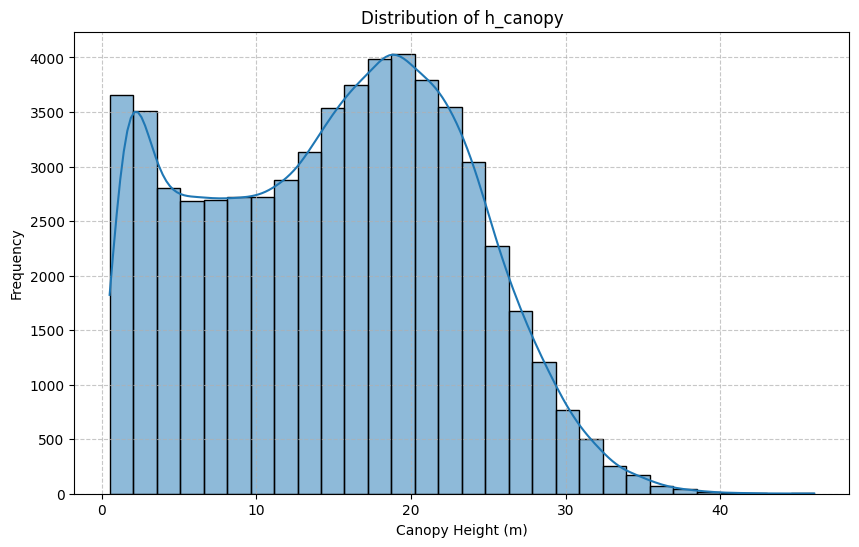

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(canopy_embedding_df['h_canopy'], kde=True, bins=30)
plt.title('Distribution of h_canopy')
plt.xlabel('Canopy Height (m)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Feature Importance Analysis

In [14]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import numpy as np

# Define features (X) and target (y)
# Drop identifier columns and the target itself
X = canopy_embedding_df.drop(columns=['geosegmentUID', 'h_canopy_source_column', 'h_canopy'])
y = canopy_embedding_df['h_canopy']

# Initialize and train a Random Forest Regressor
# Using a small number of estimators for speed, can be increased for more accurate results
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X, y)

# Get feature importances
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

print('Top 10 Feature Importances:')
display(features_df.head(10))

Top 10 Feature Importances:


,Feature,Importance
42,A40,0.231671
22,A20,0.118955
26,A24,0.087508
52,A50,0.044531
4,A02,0.042491
57,A55,0.037955
41,A39,0.019458
62,A60,0.019453
38,A36,0.018476
34,A32,0.015964


/tmp/ipykernel_14910/2649397730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')


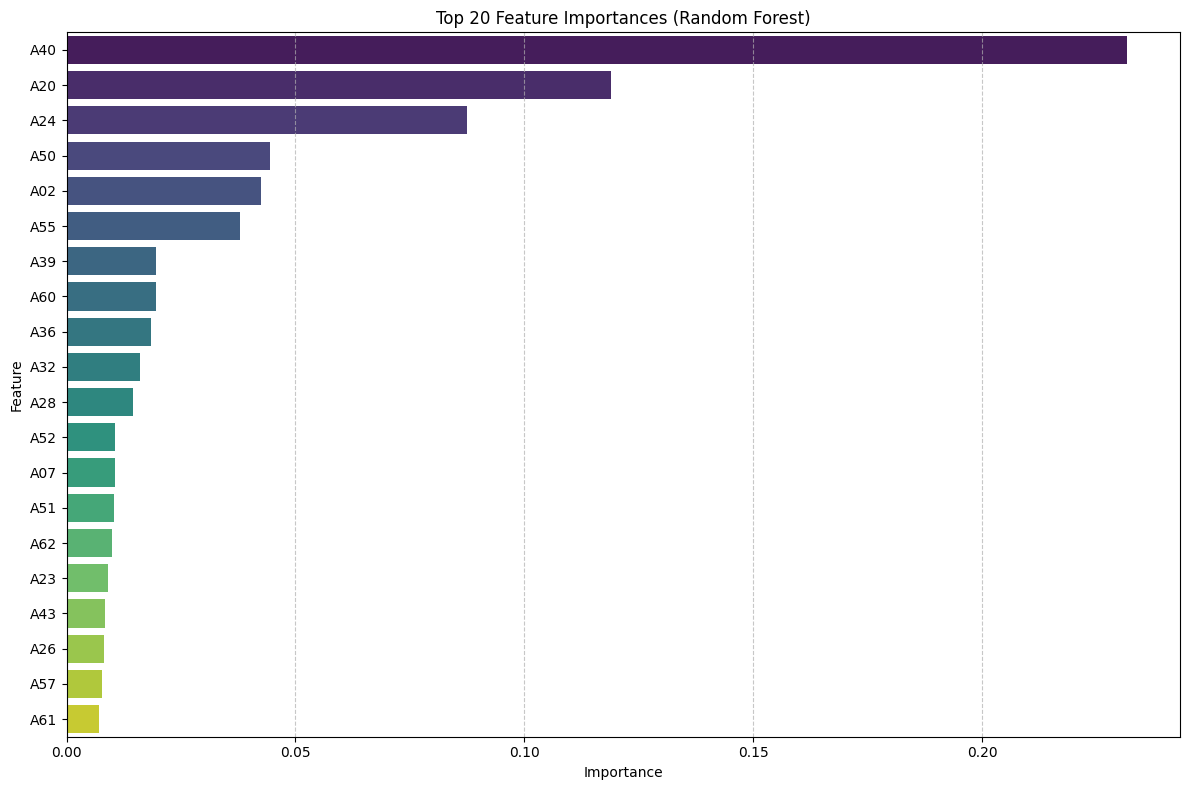

In [15]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Random Forest Model Cross-Validation

In [16]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

# Prepare features (X) and target (y) again, as defined previously
X = canopy_embedding_df.drop(columns=['geosegmentUID', 'h_canopy_source_column', 'h_canopy'])
y = canopy_embedding_df['h_canopy']

# Initialize K-Fold Cross-Validation
# n_splits determines the number of folds (e.g., 5-fold CV)
# shuffle=True to randomize the data before splitting
# random_state for reproducibility
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# List to store RMSE for each fold
rmse_scores = []

print('Performing 5-fold Cross-Validation...')

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Initialize and train the Random Forest Regressor for the current fold
    # Using the same parameters as in the feature importance step
    fold_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    fold_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = fold_model.predict(X_test)

    # Calculate RMSE for the current fold
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_scores.append(rmse)
    print(f'Fold {fold+1} - RMSE: {rmse:.4f}')

# Print the average RMSE across all folds
average_rmse = np.mean(rmse_scores)
print(f'\nAverage RMSE across all folds: {average_rmse:.4f}')
print(f'Standard deviation of RMSE across all folds: {np.std(rmse_scores):.4f}')

Performing 5-fold Cross-Validation...
Fold 1 - RMSE: 4.7938
Fold 2 - RMSE: 4.7109
Fold 3 - RMSE: 4.7198
Fold 4 - RMSE: 4.7586
Fold 5 - RMSE: 4.7341

Average RMSE across all folds: 4.7434
Standard deviation of RMSE across all folds: 0.0299


### Predicted vs. Actual h_canopy Scatter Plot

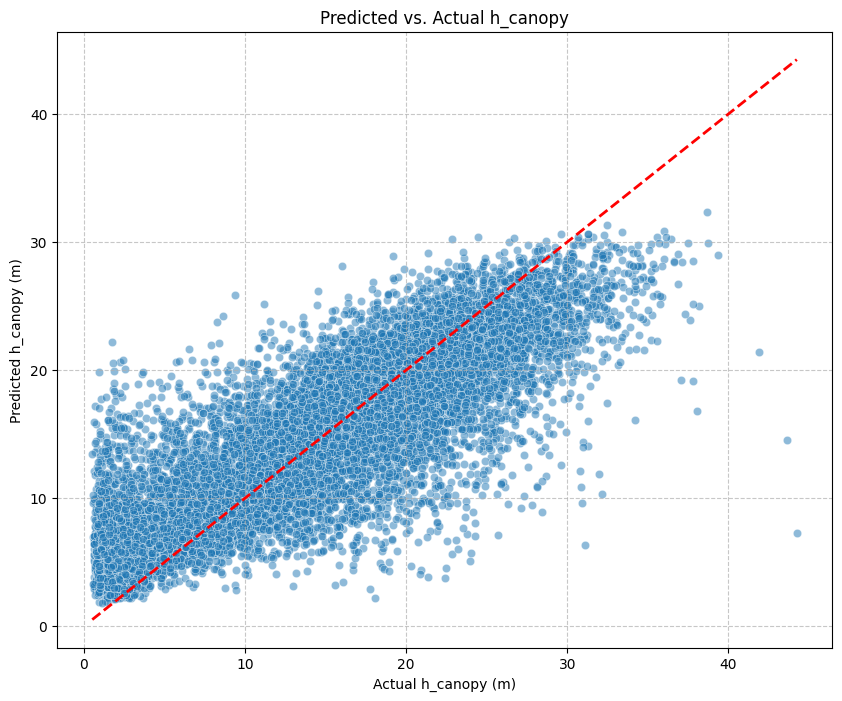

In [17]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.title('Predicted vs. Actual h_canopy')
plt.xlabel('Actual h_canopy (m)')
plt.ylabel('Predicted h_canopy (m)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Hyperparameter Tuning for Random Forest Regressor

In [19]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_features': [0.6, 0.8, 1.0], # Number of features to consider at every split
    'min_samples_leaf': [1, 2, 4],   # Minimum number of samples required at each leaf node
}

# Initialize a new Random Forest Regressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize GridSearchCV
# verbose=2 will print the progress for each combination
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='neg_root_mean_squared_error', verbose=2, n_jobs=-1)

print("Starting GridSearchCV for hyperparameter tuning...")
# Fit GridSearchCV to the full dataset (X, y)
# Note: This can take a significant amount of time depending on the data size and grid complexity
grid_search.fit(X, y)

print("Hyperparameter tuning completed.")

# Get the best parameters and the best score
best_params = grid_search.best_params_
best_rmse = -grid_search.best_score_ # Convert negative RMSE back to positive

print(f"\nBest Hyperparameters: {best_params}")
print(f"Best Cross-validated RMSE: {best_rmse:.4f}")

# Train the final model with the best parameters
best_rf_model = grid_search.best_estimator_
print("\nFinal Random Forest model trained with best parameters:")
display(best_rf_model)

Starting GridSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


KeyboardInterrupt: 

### Visualization of Hyperparameter Tuning Results

In [ ]:
results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(14, 6))
sns.lineplot(data=results, x='param_n_estimators', y='mean_test_score', hue='param_max_features', style='param_min_samples_leaf', marker='o')
plt.title('Hyperparameter Tuning Results (Mean RMSE)')
plt.xlabel('n_estimators')
plt.ylabel('Mean Negative Root Mean Squared Error (Higher is Better)')
plt.legend(title='Parameters')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Multi-layer Perceptron (MLP) Model with Hyperparameter Tuning

In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Prepare features (X) and target (y) again
X = canopy_embedding_df.drop(columns=['geosegmentUID', 'h_canopy_source_column', 'h_canopy'])
y = canopy_embedding_df['h_canopy']

# It's good practice to scale data for neural networks
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=42, max_iter=500)) # Increased max_iter for convergence
])

# Define the parameter grid for MLP Regressor
param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50)], # Single or double hidden layers
    'mlp__activation': ['relu', 'tanh'], # Activation function for the hidden layer
    'mlp__solver': ['adam'], # Optimizer for weight optimization
    'mlp__alpha': [0.0001, 0.001], # L2 penalty (regularization term) parameter
}

# Initialize GridSearchCV for MLP
# Using a smaller cv=2 for faster execution; can be increased for more robust tuning
grid_search_mlp = GridSearchCV(estimator=pipeline, param_grid=param_grid_mlp, cv=2,
                               scoring='neg_root_mean_squared_error', verbose=2, n_jobs=-1)

print("Starting GridSearchCV for MLP hyperparameter tuning...")
grid_search_mlp.fit(X, y)

print("MLP Hyperparameter tuning completed.")

# Get the best parameters and the best score
best_params_mlp = grid_search_mlp.best_params_
best_rmse_mlp = -grid_search_mlp.best_score_ # Convert negative RMSE back to positive

print(f"\nBest MLP Hyperparameters: {best_params_mlp}")
print(f"Best Cross-validated MLP RMSE: {best_rmse_mlp:.4f}")

# Train the final MLP model with the best parameters
best_mlp_model = grid_search_mlp.best_estimator_
print("\nFinal MLP model trained with best parameters:")
display(best_mlp_model)

Starting GridSearchCV for MLP hyperparameter tuning...
Fitting 2 folds for each of 12 candidates, totalling 24 fits
MLP Hyperparameter tuning completed.

Best MLP Hyperparameters: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (50,), 'mlp__solver': 'adam'}
Best Cross-validated MLP RMSE: 4.6114

Final MLP model trained with best parameters:


Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPRegressor(alpha=0.001, hidden_layer_sizes=(50,),
                              max_iter=500, random_state=42))])

### Predicted vs. Actual h_canopy Scatter Plot (MLP Model)

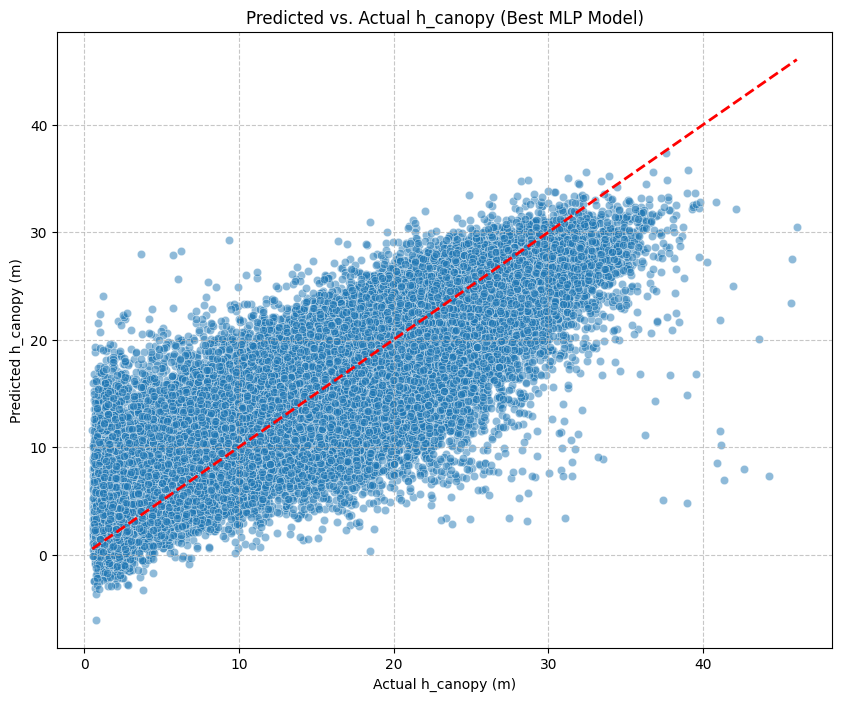

In [21]:
y_pred_mlp = best_mlp_model.predict(X)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y, y=y_pred_mlp, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect prediction line
plt.title('Predicted vs. Actual h_canopy (Best MLP Model)')
plt.xlabel('Actual h_canopy (m)')
plt.ylabel('Predicted h_canopy (m)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Visualization of MLP Hyperparameter Tuning Results

/tmp/ipykernel_14910/1795933205.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mlp_plot_data['mean_test_score'] = -mlp_plot_data['mean_test_score'] # Convert back to positive RMSE
/tmp/ipykernel_14910/1795933205.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mlp_plot_data['param_mlp__hidden_layer_sizes'] = mlp_plot_data['param_mlp__hidden_layer_sizes'].astype(str)


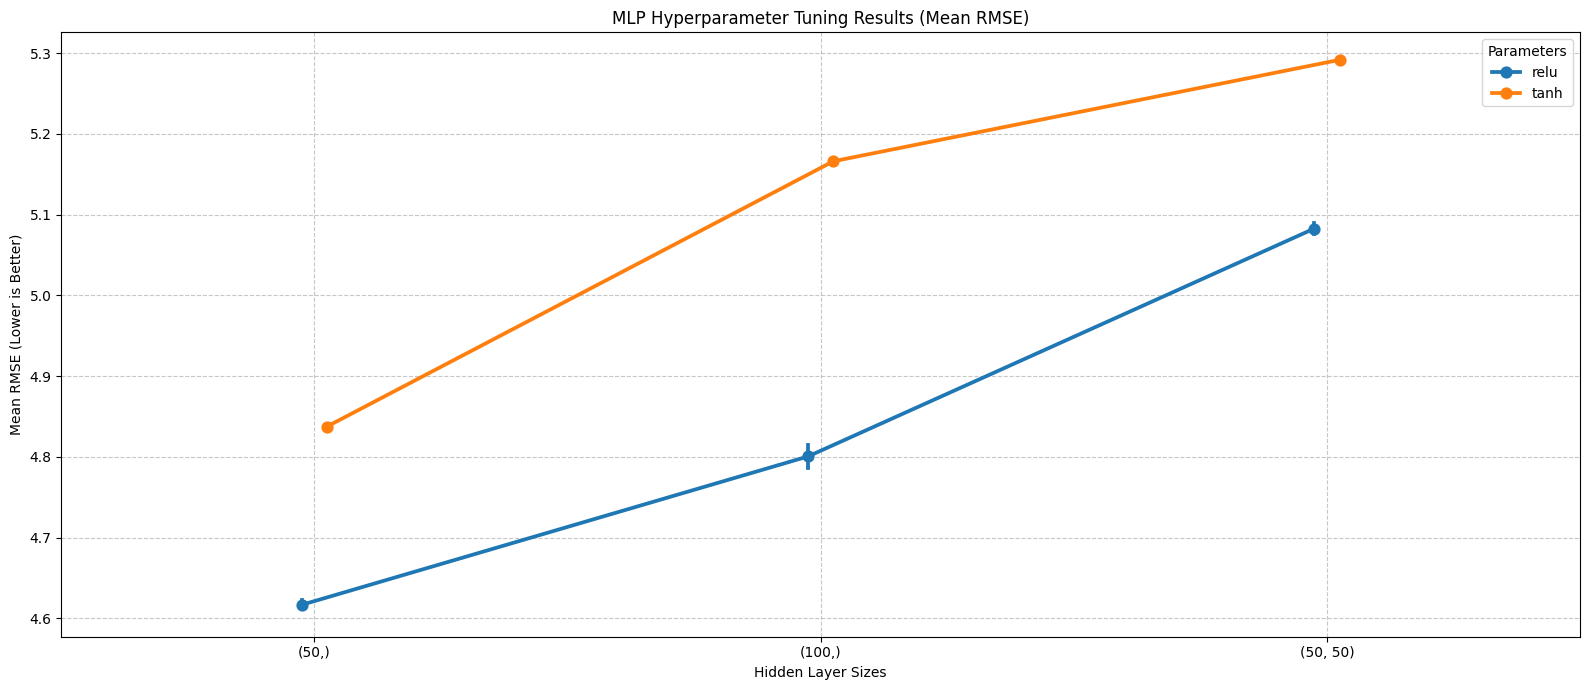

In [26]:
mlp_results = pd.DataFrame(grid_search_mlp.cv_results_)

# Extract relevant columns for plotting
mlp_plot_data = mlp_results[['param_mlp__hidden_layer_sizes', 'param_mlp__activation', 'param_mlp__alpha', 'mean_test_score']]
mlp_plot_data['mean_test_score'] = -mlp_plot_data['mean_test_score'] # Convert back to positive RMSE

# Convert 'param_mlp__hidden_layer_sizes' to string for proper categorical plotting
mlp_plot_data['param_mlp__hidden_layer_sizes'] = mlp_plot_data['param_mlp__hidden_layer_sizes'].astype(str)

# Plotting mean RMSE for different hidden_layer_sizes and activation functions using pointplot
plt.figure(figsize=(16, 7))
sns.pointplot(data=mlp_plot_data, x='param_mlp__hidden_layer_sizes', y='mean_test_score',
             hue='param_mlp__activation', marker='o', dodge=True) # Removed style argument

plt.title('MLP Hyperparameter Tuning Results (Mean RMSE)')
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Mean RMSE (Lower is Better)')
plt.legend(title='Parameters')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparison of Random Forest and MLP Model Performance

In [24]:
print(f"Average RMSE of Random Forest Model (Cross-Validation): {average_rmse:.4f}")
print(f"Best Cross-validated RMSE of MLP Model: {best_rmse_mlp:.4f}")

if best_rmse_mlp < average_rmse:
    print("\nThe MLP model achieved a slightly lower (better) RMSE compared to the Random Forest model.")
elif best_rmse_mlp > average_rmse:
    print("\nThe Random Forest model achieved a slightly lower (better) RMSE compared to the MLP model.")
else:
    print("\nBoth models achieved similar RMSE performance.")

Average RMSE of Random Forest Model (Cross-Validation): 4.7434
Best Cross-validated RMSE of MLP Model: 4.6114

The MLP model achieved a slightly lower (better) RMSE compared to the Random Forest model.


### Feature Importance Analysis for MLP Model (Permutation Importance)

In [27]:
from sklearn.inspection import permutation_importance

# Ensure X and y are defined (as they might have been used in previous cells)
X = canopy_embedding_df.drop(columns=['geosegmentUID', 'h_canopy_source_column', 'h_canopy'])
y = canopy_embedding_df['h_canopy']

print("Calculating permutation importances for the best MLP model...")
# Calculate permutation importance on the test set.
# Use the 'neg_root_mean_squared_error' metric for consistency with GridSearchCV.
result = permutation_importance(best_mlp_model, X, y, n_repeats=10, random_state=42, n_jobs=-1,
                                scoring='neg_root_mean_squared_error')

# The permutation importance result object contains 'importances_mean' and 'importances_std'
# We want to sort by the mean importance.
mlp_feature_importances = pd.Series(result.importances_mean, index=X.columns)
mlp_feature_importances = mlp_feature_importances.sort_values(ascending=False)

print('Top 10 Feature Importances for MLP Model (Permutation Importance):')
display(mlp_feature_importances.head(10))

Calculating permutation importances for the best MLP model...
Top 10 Feature Importances for MLP Model (Permutation Importance):


,0
A51,0.737911
A55,0.678680
A40,0.622715
A39,0.611927
A63,0.597615
A47,0.572244
A02,0.519320
A36,0.499242
A30,0.442349
A24,0.411808


/tmp/ipykernel_14910/3373644585.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mlp_feature_importances.head(20).values, y=mlp_feature_importances.head(20).index, palette='viridis')


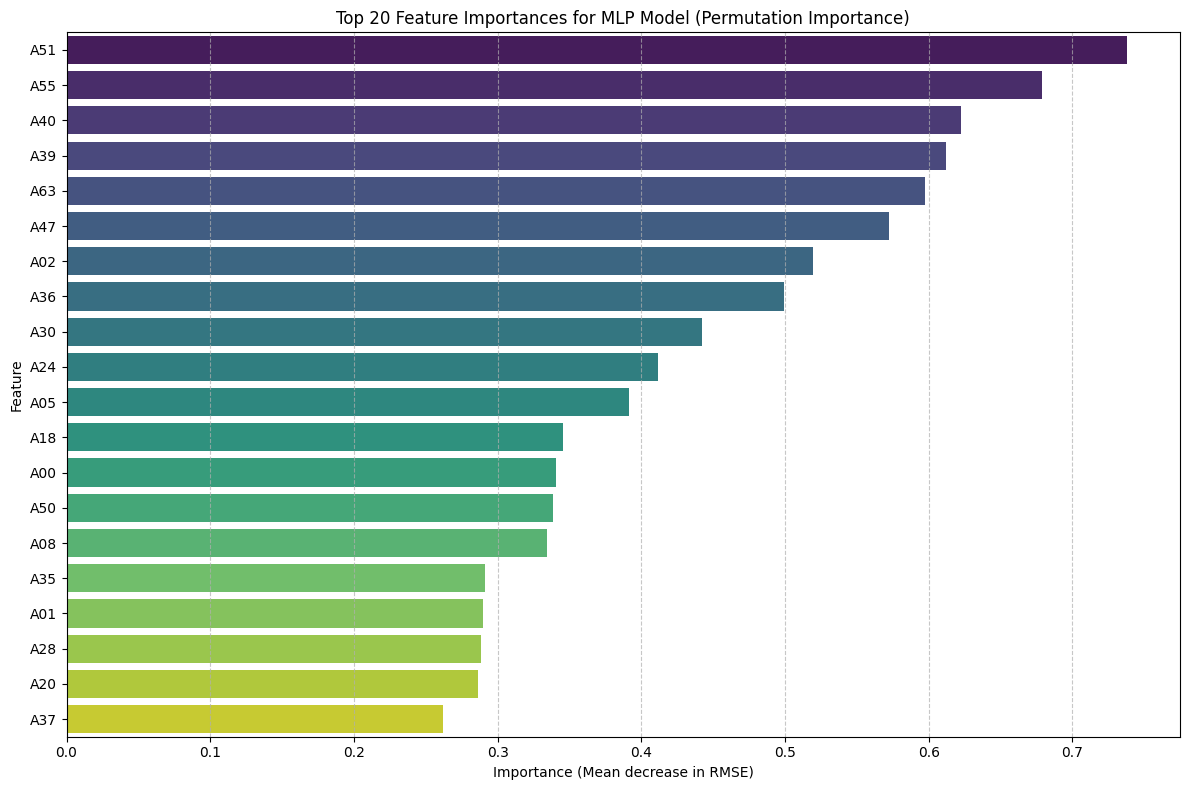

In [28]:
plt.figure(figsize=(12, 8))
sns.barplot(x=mlp_feature_importances.head(20).values, y=mlp_feature_importances.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances for MLP Model (Permutation Importance)')
plt.xlabel('Importance (Mean decrease in RMSE)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparison of Feature Importances: Random Forest vs. MLP

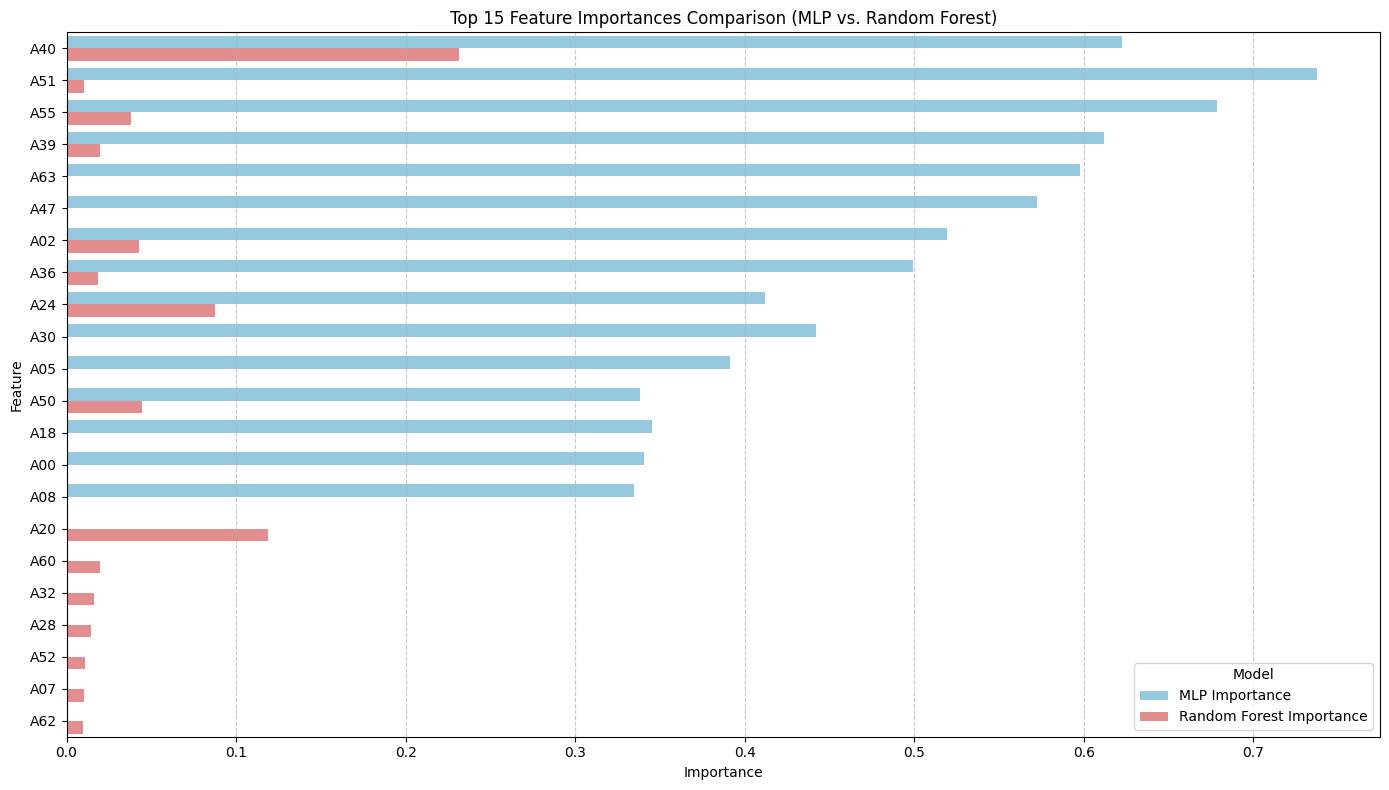

In [31]:
# Rename the MLP importance series for clarity in plotting
mlp_feature_importances_df = mlp_feature_importances.reset_index()
mlp_feature_importances_df.columns = ['Feature', 'MLP Importance']

# Get the Random Forest feature importances (features_df is already available)
rf_feature_importances_df = features_df.rename(columns={'Importance': 'Random Forest Importance'})

# Merge the two dataframes on the 'Feature' column
# Taking the top N features from both for a cleaner comparison
top_n = 15 # You can adjust this number

# Get top N features from MLP
top_mlp_features = mlp_feature_importances_df.head(top_n)

# Get top N features from Random Forest
top_rf_features = rf_feature_importances_df.head(top_n)

# Combine and melt for easier plotting with seaborn
combined_importances = pd.merge(top_mlp_features, top_rf_features, on='Feature', how='outer')

# Fill NaN values with 0 if a feature is present in one but not the other top N
combined_importances = combined_importances.fillna(0)

# Sort by overall importance for better visualization
combined_importances['Total Importance'] = combined_importances['MLP Importance'] + combined_importances['Random Forest Importance']
combined_importances = combined_importances.sort_values(by='Total Importance', ascending=False)

# Melt for seaborn barplot
importances_melted = combined_importances.melt(id_vars=['Feature', 'Total Importance'], var_name='Model', value_name='Importance')

plt.figure(figsize=(14, 8))
sns.barplot(x='Importance', y='Feature', hue='Model', data=importances_melted.sort_values(by='Total Importance', ascending=False), palette={'MLP Importance': 'skyblue', 'Random Forest Importance': 'lightcoral'})
plt.title(f'Top {top_n} Feature Importances Comparison (MLP vs. Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Saving the Best MLP Model

In [29]:
import joblib

# Define the path to save the model
model_save_path = '/content/drive/MyDrive/best_mlp_model.joblib'

# Save the best MLP model
joblib.dump(best_mlp_model, model_save_path)

print(f"Best MLP model saved successfully to: {model_save_path}")

Best MLP model saved successfully to: /content/drive/MyDrive/best_mlp_model.joblib


#Prediction Model

Use embedings to predict the canopy height of each lidar segement at by 11m by 20m spatial resolution